# Loan Default Data — Preprocessing & Visualization

A simple, beginner-friendly notebook that:
1. Loads the data
2. Explores it (shape, types, missing values)
3. Cleans it (missing values, duplicates)
4. Encodes categorical columns
5. Visualizes numeric columns with **Histogram + KDE** and **Boxplots**
6. Removes outliers using the **IQR method**
7. Shows before vs after comparison
8. Saves the cleaned dataset

Dataset: `Loan_default.csv`


In [1]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default look for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)


## Step 1: Load the Data

In [2]:
# Load the CSV file
df = pd.read_csv("Loan_default.csv")

print("Shape of data:", df.shape)
df.head()


Shape of data: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Step 2: Explore the Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
# Check missing values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [6]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## Step 3: Basic Cleaning
- Drop duplicate rows (if any)
- Drop an ID column (not useful for analysis)
- Handle missing values (fill numeric with median, categorical with mode)


In [7]:
# Drop duplicates
df = df.drop_duplicates()

# Drop ID column (not useful for stats/plots)
if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])

# Fill missing values
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())
df.head()


Missing values after cleaning:
0


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Step 4: Identify Numeric Columns for Visualization

In [8]:
# Numeric columns we will visualize (exclude the target 'Default' which is 0/1)
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                 'LoanTerm', 'DTIRatio']

# Keep only columns that actually exist in the dataframe
numeric_cols = [c for c in numeric_cols if c in df.columns]
numeric_cols


['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio']

## Step 5: Histogram + KDE (Before Removing Outliers)

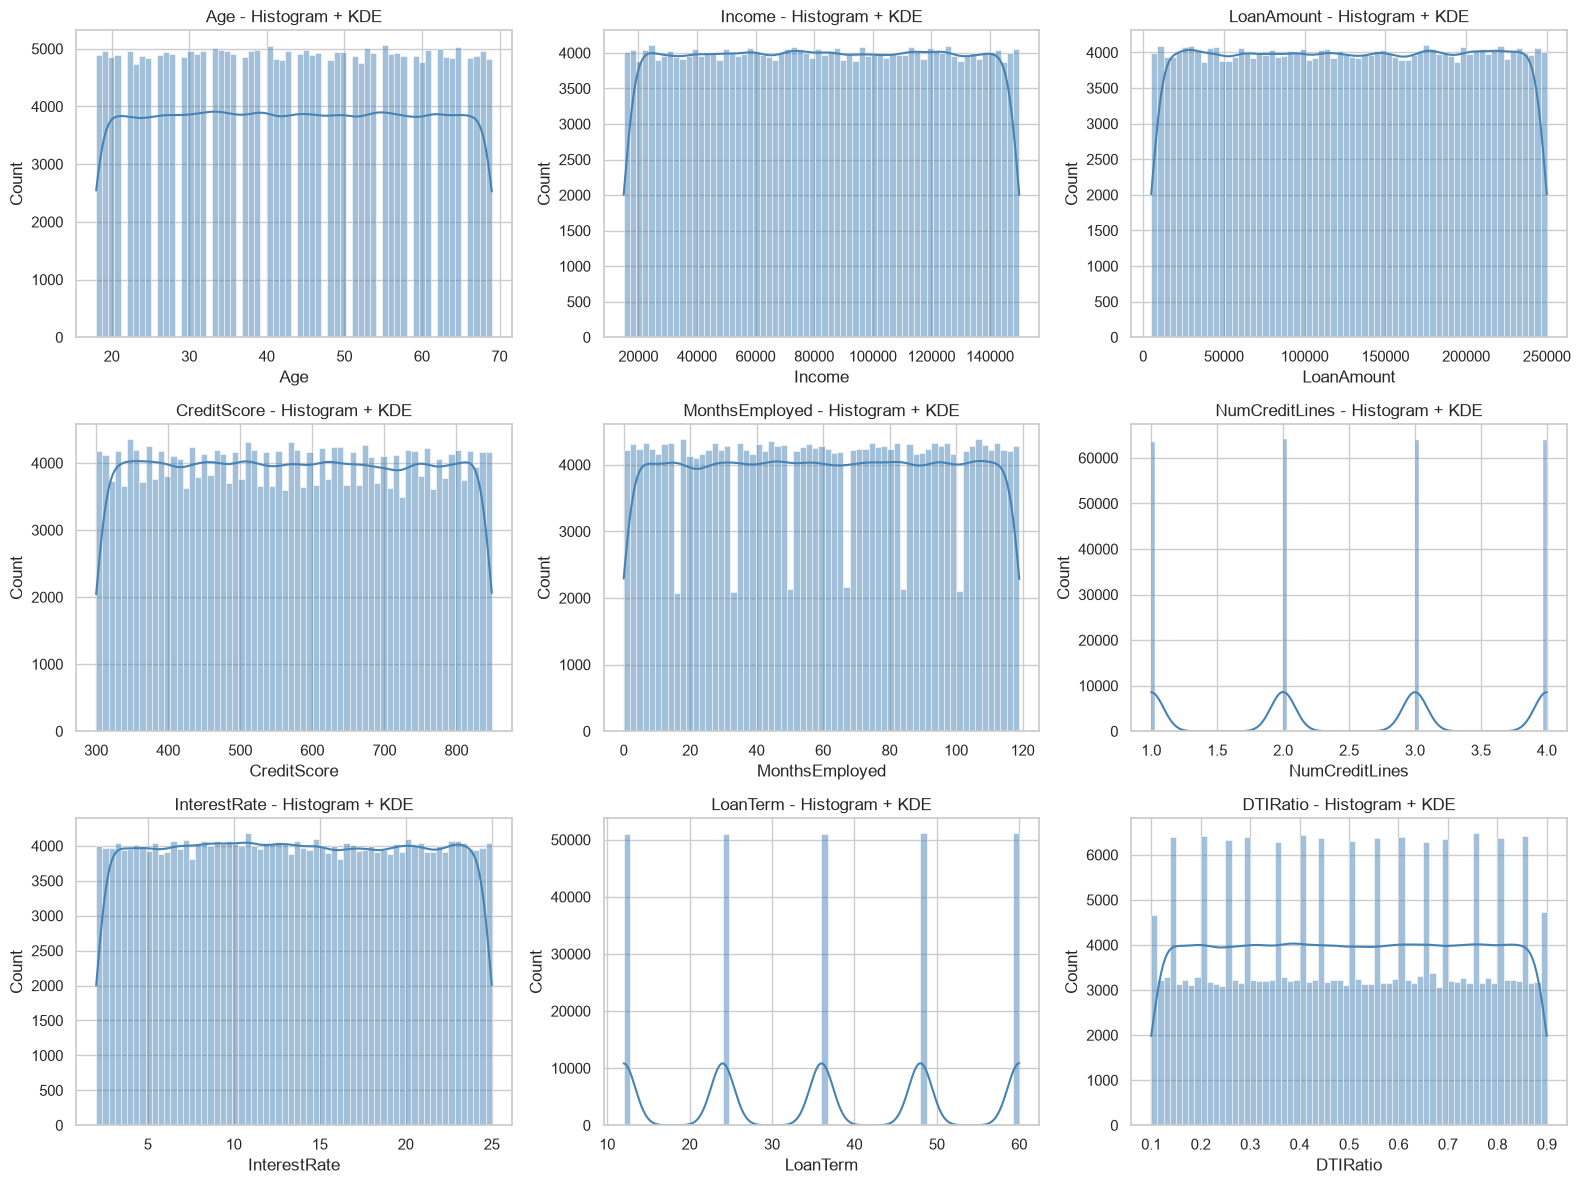

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} - Histogram + KDE')

# Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 6: Boxplots (Before Removing Outliers)

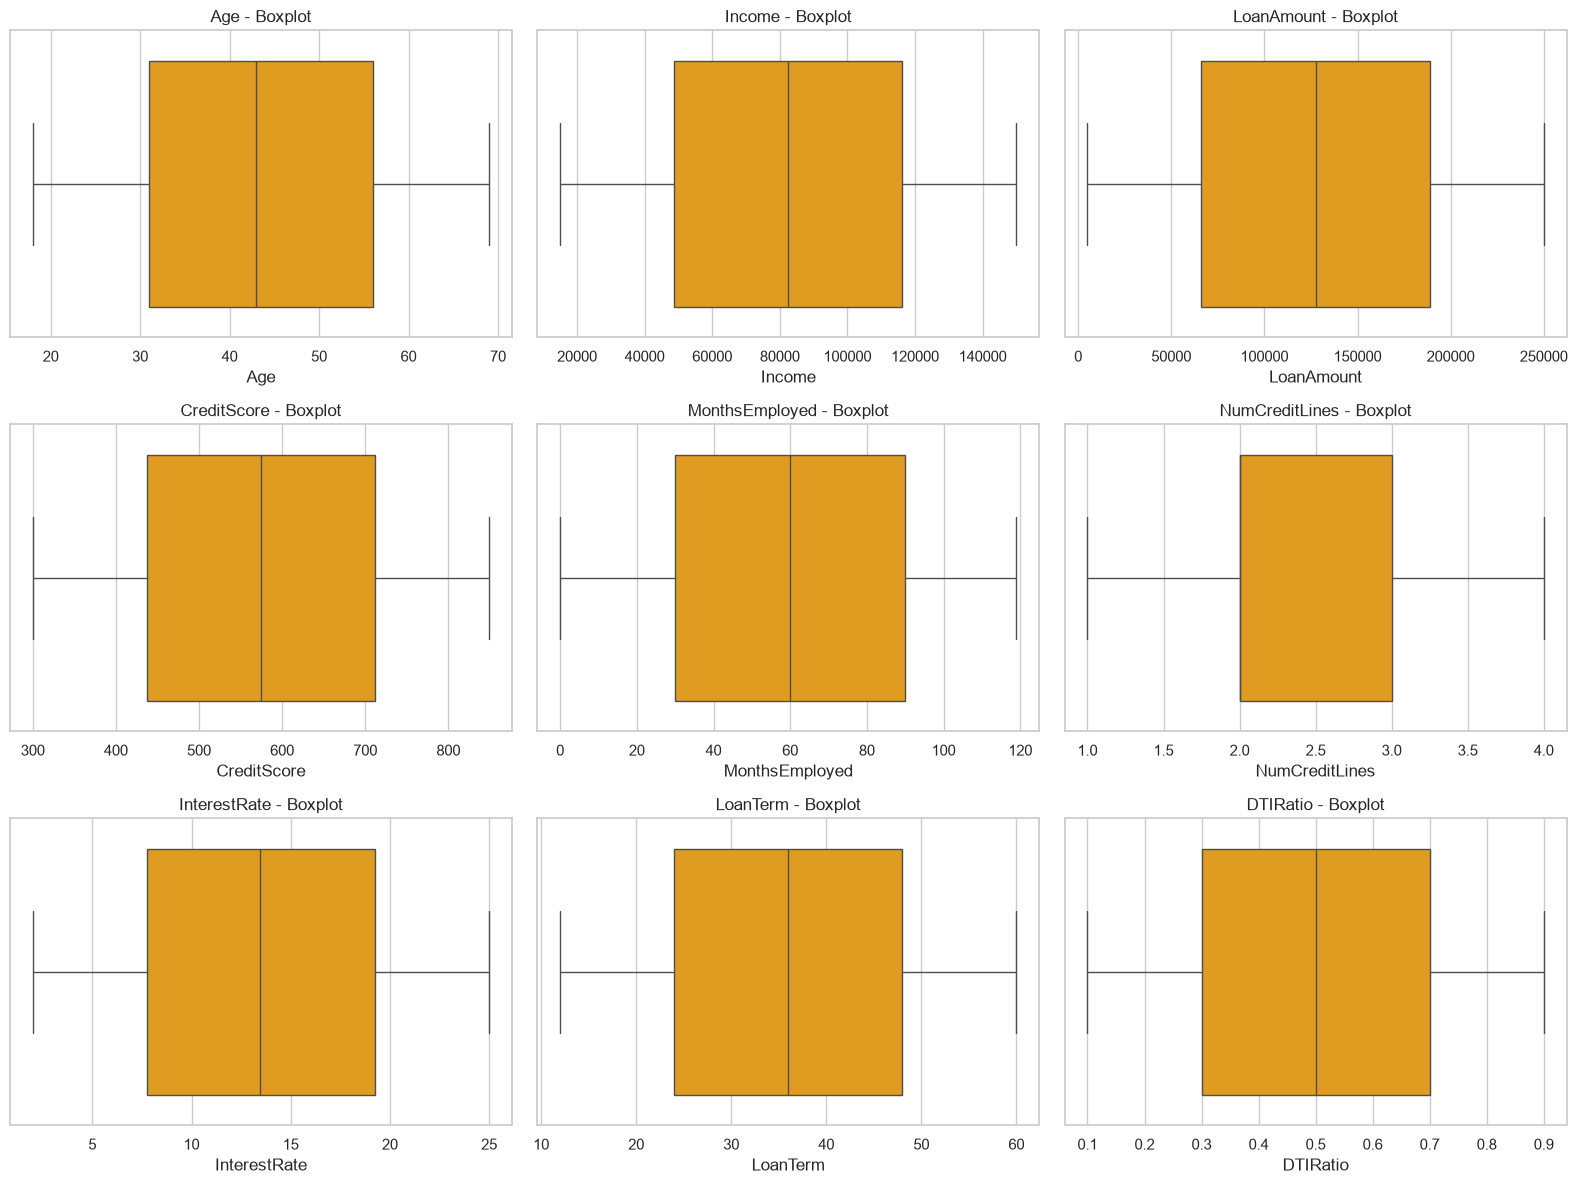

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='orange')
    axes[i].set_title(f'{col} - Boxplot')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Step 7: Remove Outliers (IQR Method)

The **IQR (Interquartile Range) method** is the simplest and most common way to remove outliers:

- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier and removed.


In [12]:
def remove_outliers_iqr(data, columns):
    cleaned = data.copy()
    for col in columns:
        Q1 = cleaned[col].quantile(0.25)
        Q3 = cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        before = cleaned.shape[0]
        cleaned = cleaned[(cleaned[col] >= lower_bound) & (cleaned[col] <= upper_bound)]
        after = cleaned.shape[0]
        print(f"{col}: removed {before - after} outlier rows")
    return cleaned

df_no_outliers = remove_outliers_iqr(df, numeric_cols)

print("\nOriginal shape:", df.shape)
print("Shape after removing outliers:", df_no_outliers.shape)


Age: removed 0 outlier rows
Income: removed 0 outlier rows
LoanAmount: removed 0 outlier rows
CreditScore: removed 0 outlier rows
MonthsEmployed: removed 0 outlier rows
NumCreditLines: removed 0 outlier rows
InterestRate: removed 0 outlier rows
LoanTerm: removed 0 outlier rows
DTIRatio: removed 0 outlier rows

Original shape: (255347, 17)
Shape after removing outliers: (255347, 17)


## Step 8: Histogram + KDE (After Removing Outliers)

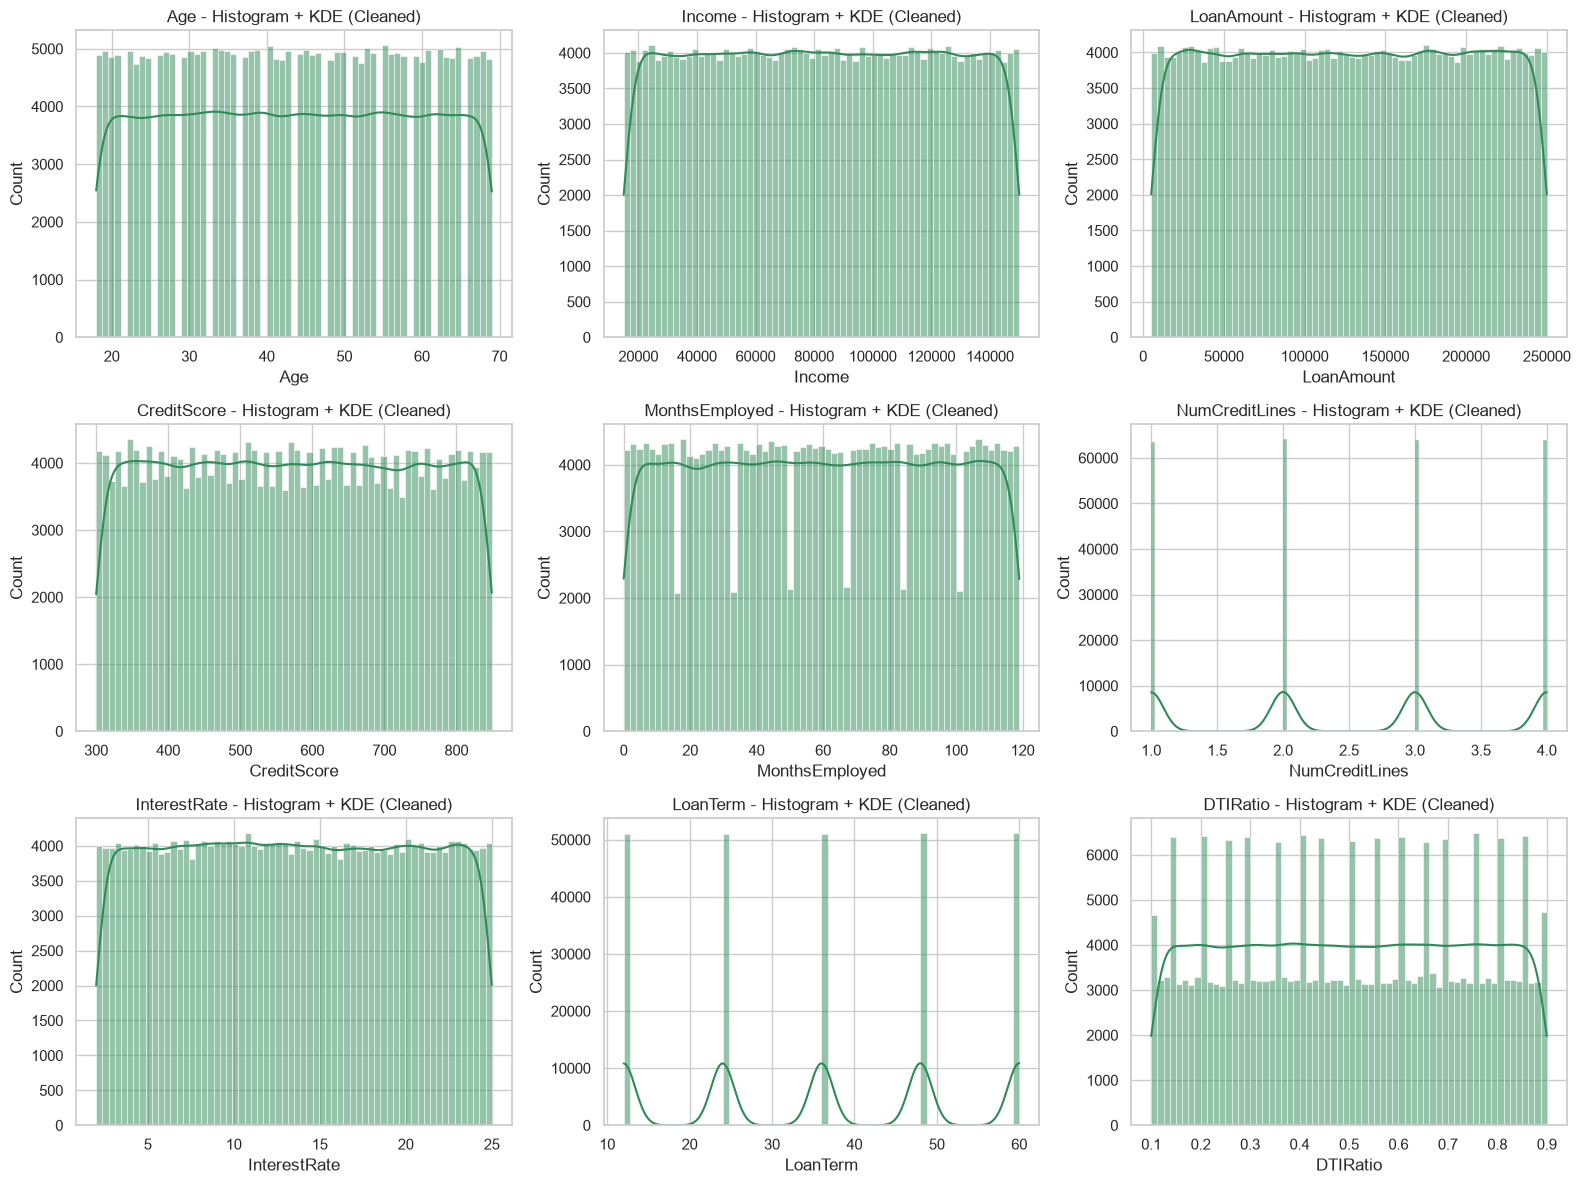

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_no_outliers[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(f'{col} - Histogram + KDE (Cleaned)')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Step 9: Boxplots (After Removing Outliers)

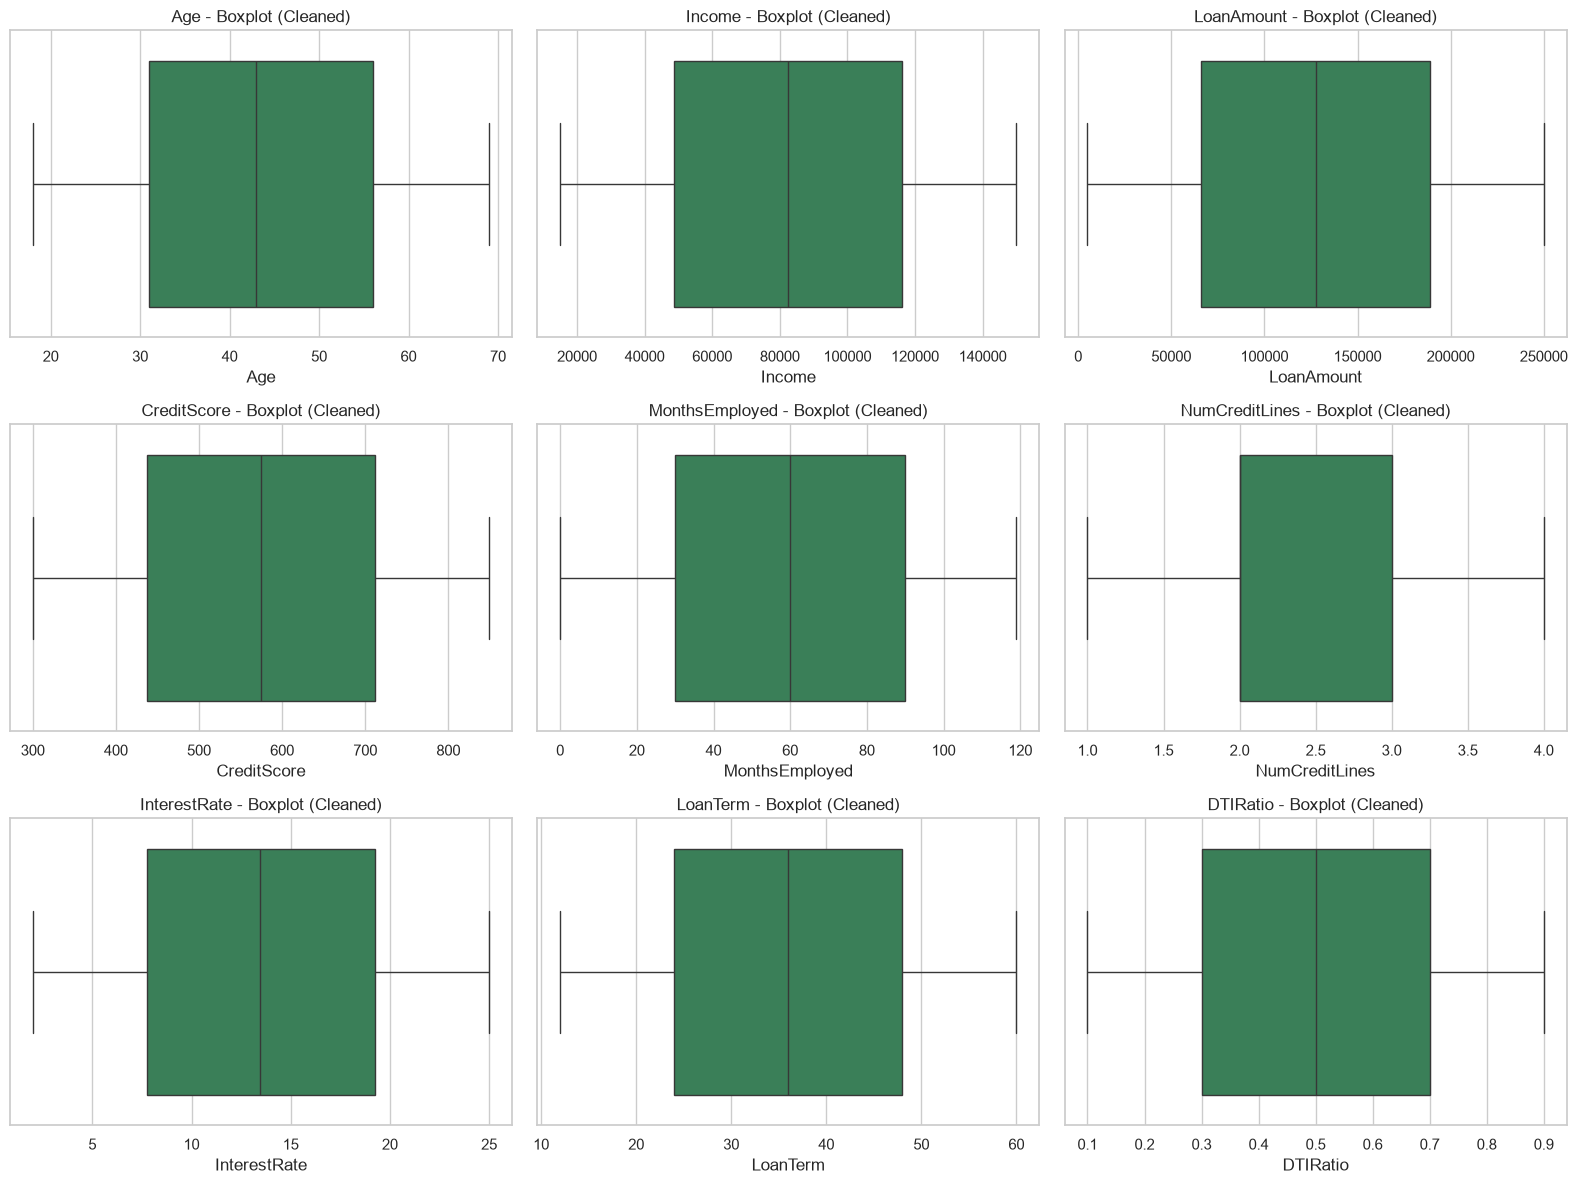

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_no_outliers[col], ax=axes[i], color='seagreen')
    axes[i].set_title(f'{col} - Boxplot (Cleaned)')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Step 10: Encode Categorical Columns (Optional — for ML use)

Many ML models need numbers, not text. Here we use simple **Label Encoding**
for categorical columns.


In [15]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_no_outliers.copy()
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()


C:\Users\Admin\AppData\Local\Temp\ipykernel_18344\3131295537.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()


Categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


## Step 11 (Bonus): Correlation Heatmap

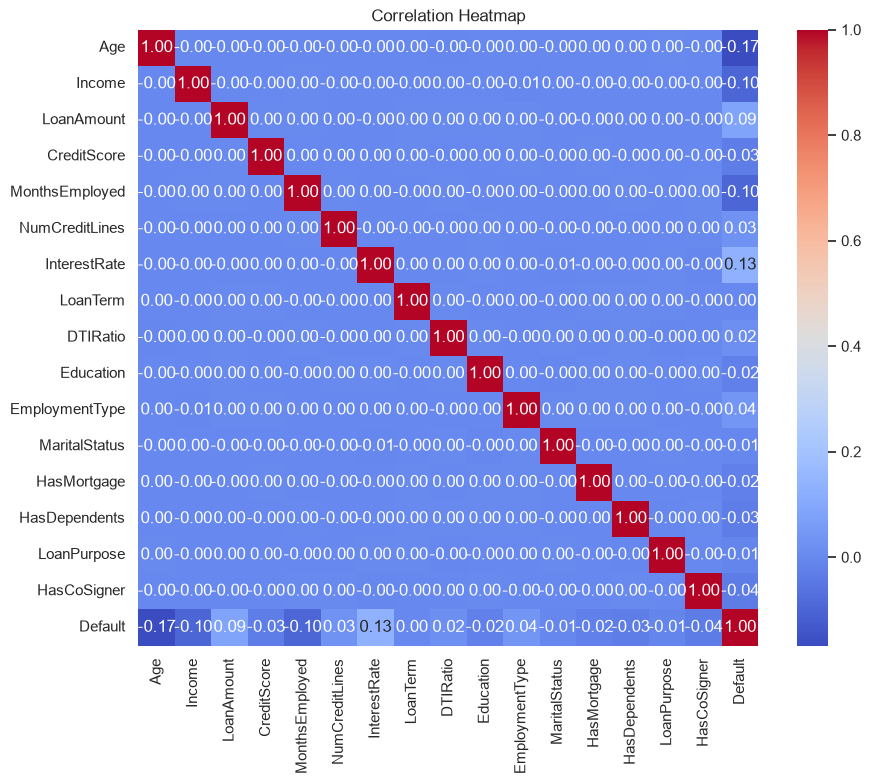

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Step 12: Save the Cleaned Dataset

In [17]:
df_no_outliers.to_csv("Loan_default_cleaned.csv", index=False)
df_encoded.to_csv("Loan_default_cleaned_encoded.csv", index=False)

print("Saved: Loan_default_cleaned.csv (outliers removed, original text categories)")
print("Saved: Loan_default_cleaned_encoded.csv (outliers removed + label encoded)")


Saved: Loan_default_cleaned.csv (outliers removed, original text categories)
Saved: Loan_default_cleaned_encoded.csv (outliers removed + label encoded)


## Summary

- Loaded the dataset and checked for missing values / duplicates
- Cleaned missing values and dropped the ID column
- Visualized every numeric column with **Histogram + KDE** and **Boxplot**
- Removed outliers using the **IQR method**
- Compared distributions before vs after cleaning
- Encoded categorical columns for ML readiness
- Saved the final cleaned CSV files

You can now use `Loan_default_cleaned_encoded.csv` directly for machine learning models.
